In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import torch
import torch.nn as nn
import lightning as L

In [3]:
df = pd.read_csv("restaurant_deliveries_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order Date          50000 non-null  object 
 1   Customer Latitude   50000 non-null  float64
 2   Customer Longitude  50000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 1.1+ MB


In [4]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Order Date          50000 non-null  datetime64[ns]
 1   Customer Latitude   50000 non-null  float64       
 2   Customer Longitude  50000 non-null  float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 1.1 MB


In [5]:
scaler = StandardScaler()
df[["Latitude_Scaled", "Longitude_Scaled"]] = scaler.fit_transform(df[["Customer Latitude", "Customer Longitude"]])
df.head()

,Order Date,Customer Latitude,Customer Longitude,Latitude_Scaled,Longitude_Scaled
0,2024-04-12,6.995278,79.795438,1.314191,-1.251001
1,2024-12-14,6.883918,79.859301,-0.829003,-0.033932
2,2024-09-27,6.848062,79.787815,-1.519070,-1.396282
3,2024-04-16,6.908621,79.941768,-0.353568,1.537662
4,2024-03-12,7.000688,79.855024,1.418312,-0.115444


In [6]:
def elbow_method(data, max_k):
    means = []
    inertias = []
    for k1 in range(1, max_k+1):
        kmeans_elbow = KMeans(n_clusters=k1)
        kmeans_elbow.fit(data)
        means.append(k1)
        inertias.append(kmeans_elbow.inertia_)
    
    plt.plot(means, inertias, 'o-')
    plt.title("Elbow Method")
    plt.xlabel("Number of Clusters")
    plt.ylabel("Intertia")
    plt.grid(True)
    plt.show()

c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  

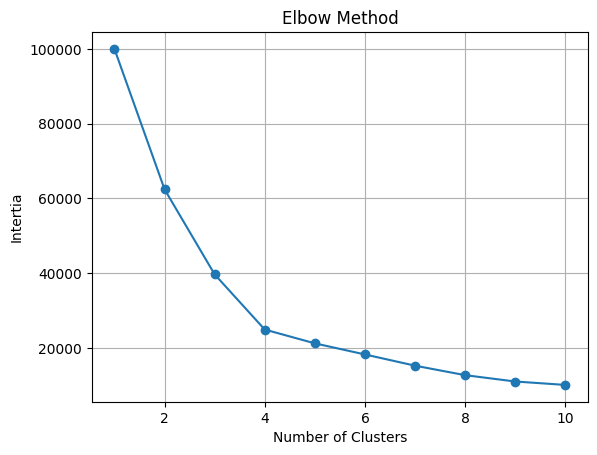

In [7]:
elbow_method(df[["Latitude_Scaled", "Longitude_Scaled"]], 10)

In [8]:
kmeans_optmial = KMeans(n_clusters=4)
kmeans_optmial.fit(df[["Latitude_Scaled", "Longitude_Scaled"]])
df["K-Means = 4"] = kmeans_optmial.labels_
df.head()

,Order Date,Customer Latitude,Customer Longitude,Latitude_Scaled,Longitude_Scaled,K-Means = 4
0,2024-04-12,6.995278,79.795438,1.314191,-1.251001,0
1,2024-12-14,6.883918,79.859301,-0.829003,-0.033932,2
2,2024-09-27,6.848062,79.787815,-1.519070,-1.396282,2
3,2024-04-16,6.908621,79.941768,-0.353568,1.537662,1
4,2024-03-12,7.000688,79.855024,1.418312,-0.115444,0


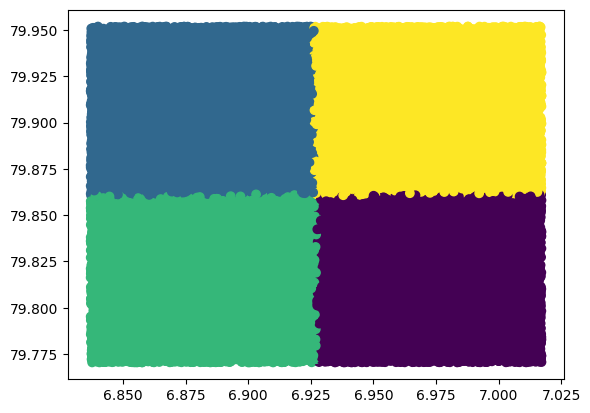

In [9]:
plt.scatter(x=df["Customer Latitude"], y=df["Customer Longitude"], c=df["K-Means = 4"])
plt.show()

In [12]:
df_cluster0 = df[df["K-Means = 4"] == 0]
df_cluster0.sort_values(by=["Order Date"], inplace=True)
df_grouped = df_cluster0.groupby(by="Order Date").size()
df_grouped = df_grouped.reset_index(name="Number of Orders")
data = df_grouped["Number of Orders"]

C:\Users\upeks\AppData\Local\Temp\ipykernel_19940\728378041.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cluster0.sort_values(by=["Order Date"], inplace=True)


In [16]:
data[1]

np.int64(27)